In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
)

In [156]:
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:.3f}")
sns.set_theme(style="darkgrid")
plt.rcParams.update(
    {
        "axes.titlesize": 10,
        "axes.labelsize": 9,
        "xtick.labelsize": 8,
        "ytick.labelsize": 9,
    }
)
RANDOM_STATE = 42
CSV_PATH = "../data/diabetes.csv"
TARGET_COL = "diabetes"

In [157]:
df = pd.read_csv(CSV_PATH)

In [158]:
df.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.000,0,1,never,25.190,6.600,140,0
1,Female,54.000,0,0,No Info,27.320,6.600,80,0
2,Male,28.000,0,0,never,27.320,5.700,158,0
3,Female,36.000,0,0,current,23.450,5.000,155,0
4,Male,76.000,1,1,current,20.140,4.800,155,0


In [159]:
df.shape

(100000, 9)

In [160]:
df.columns

Index(['gender', 'age', 'hypertension', 'heart_disease', 'smoking_history',
       'bmi', 'HbA1c_level', 'blood_glucose_level', 'diabetes'],
      dtype='str')

In [161]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  str    
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  str    
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), str(2)
memory usage: 6.9 MB


In [162]:
print("\nMissing Values")
print(df.isna().sum())


Missing Values
gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
diabetes               0
dtype: int64


In [163]:
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df.select_dtypes(exclude=[np.number]).columns.tolist()

print("Categorical Columns:", cat_cols)
print("Numerical Columns:", num_cols)
print("Target Column:", TARGET_COL)

Categorical Columns: ['gender', 'smoking_history']
Numerical Columns: ['age', 'hypertension', 'heart_disease', 'bmi', 'HbA1c_level', 'blood_glucose_level', 'diabetes']
Target Column: diabetes


In [ ]:
print("Duplicates:", df.duplicated().sum())
df = df.drop_duplicates()
print("Shape after removing duplicates:", df.shape)

Duplicates: 3854
Shape after removing duplicates: (96146, 9)


In [165]:
df.describe()

,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes
count,96146.000,96146.000,96146.000,96146.000,96146.000,96146.000,96146.000
mean,41.794,0.078,0.041,27.321,5.533,138.218,0.088
std,22.463,0.268,0.198,6.768,1.073,40.910,0.284
min,0.080,0.000,0.000,10.010,3.500,80.000,0.000
25%,24.000,0.000,0.000,23.400,4.800,100.000,0.000
50%,43.000,0.000,0.000,27.320,5.800,140.000,0.000
75%,59.000,0.000,0.000,29.860,6.200,159.000,0.000
max,80.000,1.000,1.000,95.690,9.000,300.000,1.000


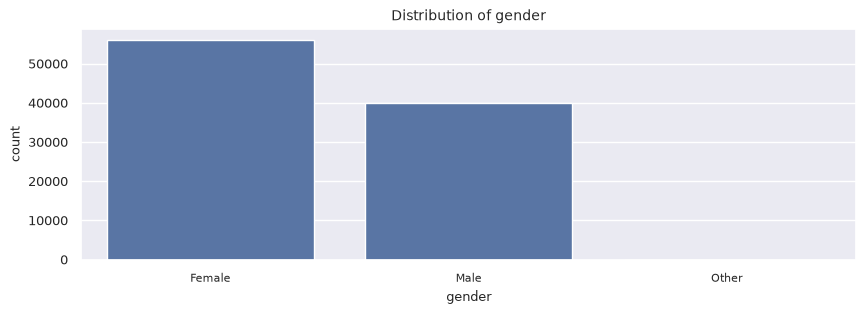

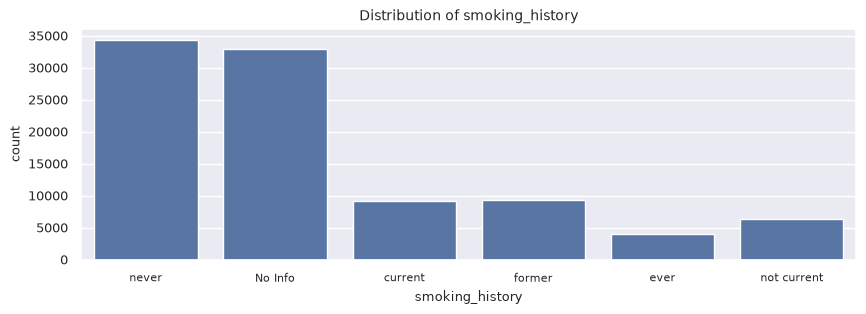

In [166]:
for col in cat_cols:
    plt.figure(figsize=(10, 3))
    sns.countplot(x=col, data=df)
    plt.title(f"Distribution of {col}")
    plt.show()

In [167]:
for col in cat_cols:
    print(df[col].value_counts())

gender
Female    56161
Male      39967
Other        18
Name: count, dtype: int64
smoking_history
never          34398
No Info        32887
former          9299
current         9197
not current     6367
ever            3998
Name: count, dtype: int64


Text(0.5, 1.0, 'Target distribution')

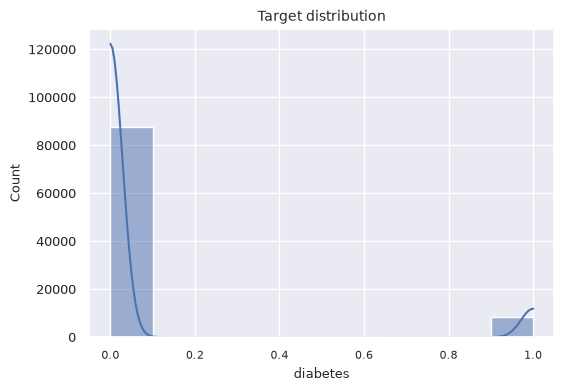

In [168]:
plt.figure(figsize=(6, 4))
sns.histplot(df[TARGET_COL], bins=10, kde=True)
plt.title("Target distribution")

In [169]:
df[TARGET_COL].value_counts()

diabetes
0    87664
1     8482
Name: count, dtype: int64

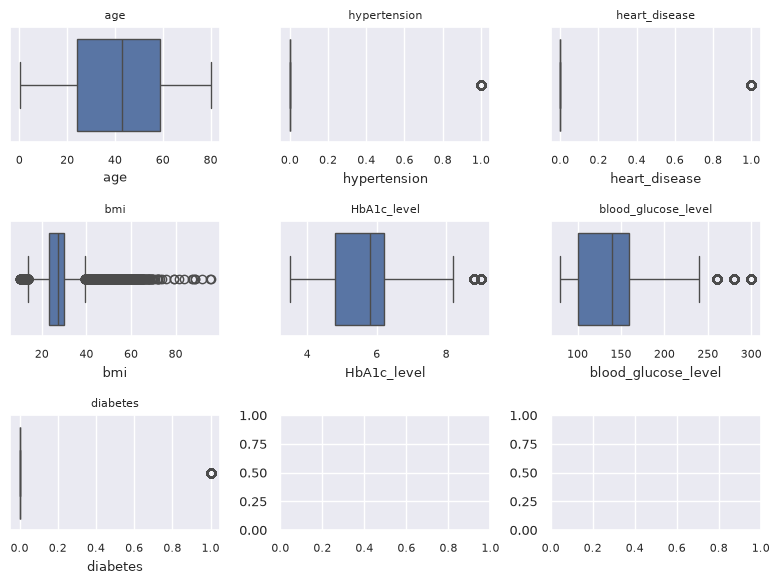

In [170]:
fig, axes = plt.subplots(3, 3, figsize=(8, 6))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(x=df[col], ax=axes[i])
    axes[i].set_title(col, fontsize=8)

plt.tight_layout()
plt.show()

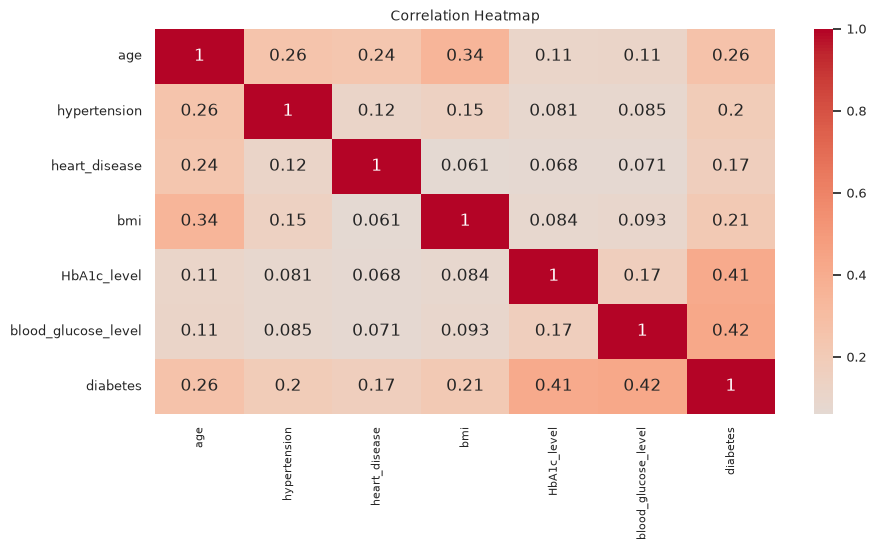

In [171]:
plt.figure(figsize=(10, 5))
sns.heatmap(df[num_cols].corr(), annot=True, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.show()

In [172]:
# to show correlation heatmap in numerical form

corr_with_target = df[num_cols].corr()[TARGET_COL].sort_values(ascending=False)
print(corr_with_target)

diabetes              1.000
blood_glucose_level   0.424
HbA1c_level           0.406
age                   0.265
bmi                   0.215
hypertension          0.196
heart_disease         0.171
Name: diabetes, dtype: float64


datapreprocessing


In [173]:
X = df.drop(columns=[TARGET_COL])
y = df[TARGET_COL]

In [174]:
X.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level
0,Female,80.000,0,1,never,25.190,6.600,140
1,Female,54.000,0,0,No Info,27.320,6.600,80
2,Male,28.000,0,0,never,27.320,5.700,158
3,Female,36.000,0,0,current,23.450,5.000,155
4,Male,76.000,1,1,current,20.140,4.800,155


In [175]:
y.head()

0    0
1    0
2    0
3    0
4    0
Name: diabetes, dtype: int64

In [176]:
# train test split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)
print("Train Shape", X_train.shape)
print("Test Shape", X_test.shape)

Train Shape (76916, 8)
Test Shape (19230, 8)


In [177]:
numerical_features = X_train.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X_train.select_dtypes(exclude=[np.number]).columns.tolist()
print("Numerical Columns:", numerical_features)
print("Categorical Columns:", categorical_features)

Numerical Columns: ['age', 'hypertension', 'heart_disease', 'bmi', 'HbA1c_level', 'blood_glucose_level']
Categorical Columns: ['gender', 'smoking_history']


In [178]:
# implementing pipeline to prevent data leakage

numerical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)
categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ]
)

preprocess = ColumnTransformer(
    transformers=[
        ("num", numerical_transformer, numerical_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

In [ ]:
baseline_pipeline = Pipeline(
    steps=[
        ("preprocess", preprocess),
        ("model", LogisticRegression(class_weight="balanced", max_iter=1000)),
    ]
)

In [180]:
baseline_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](8,)","['gender','age','hypertension',...,'bmi','HbA1c_level', 'blood_glucose_level']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,8
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, a

In [181]:
training_baseline_pred = baseline_pipeline.predict(X_train)
testing_baseline_pred = baseline_pipeline.predict(X_test)
print("train:", training_baseline_pred)

train: [0 0 0 ... 1 0 0]


Traning Data Accuracy: 0.8863565448021218
Traning Data Precision: 0.4286229271809661
Traning Data Recall: 0.8793077947049253
Classification report of training data:               precision    recall  f1-score   support

           0       0.99      0.89      0.93     70155
           1       0.43      0.88      0.58      6761

    accuracy                           0.89     76916
   macro avg       0.71      0.88      0.76     76916
weighted avg       0.94      0.89      0.90     76916

Testing Data Accuracy: 0.8862714508580343
Testing Data Precision: 0.4340317100792752
Testing Data Recall: 0.8907611853573504
Classification report of testing data:               precision    recall  f1-score   support

           0       0.99      0.89      0.93     17509
           1       0.43      0.89      0.58      1721

    accuracy                           0.89     19230
   macro avg       0.71      0.89      0.76     19230
weighted avg       0.94      0.89      0.90     19230



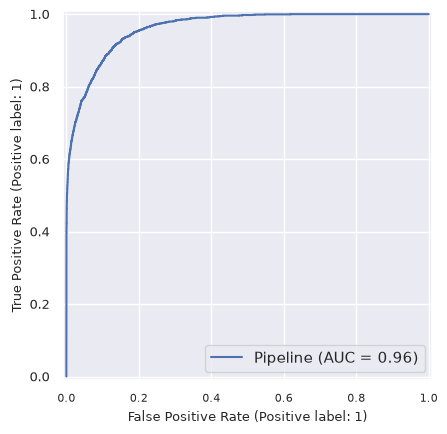

In [182]:
training_baseline_accuracy = accuracy_score(y_train, training_baseline_pred)
training_baseline_recall = recall_score(y_train, training_baseline_pred)
training_baseline_precision = precision_score(y_train, training_baseline_pred)

print("Traning Data Accuracy:", accuracy_score(y_train, training_baseline_pred))
print("Traning Data Precision:", precision_score(y_train, training_baseline_pred))
print("Traning Data Recall:", recall_score(y_train, training_baseline_pred))
print(
    "Classification report of training data:",
    classification_report(y_train, training_baseline_pred),
)


testing_baseline_accuracy = accuracy_score(y_test, testing_baseline_pred)
testing_baseline_precision = precision_score(y_test, testing_baseline_pred)
testing_baseline_recall = recall_score(y_test, testing_baseline_pred)

print("Testing Data Accuracy:", accuracy_score(y_test, testing_baseline_pred))
print("Testing Data Precision:", precision_score(y_test, testing_baseline_pred))
print("Testing Data Recall:", recall_score(y_test, testing_baseline_pred))
print(
    "Classification report of testing data:",
    classification_report(y_test, testing_baseline_pred),
)

RocCurveDisplay.from_estimator(baseline_pipeline, X_test, y_test)

Model Selection and optimization


In [ ]:
models = {
    "LogisticRegression": LogisticRegression(max_iter=1000),
    "RandomForest": RandomForestClassifier(
        n_estimators=200,
        min_samples_leaf=5,
        class_weight="balanced_subsample",
        n_jobs=-1,
        random_state=RANDOM_STATE,
    ),
    "KNeighbours": KNeighborsClassifier(
        n_neighbors=7, weights="distance", metric="minkowski"
    ),
    "SVM": SVC(C=2, kernel="rbf", class_weight="balanced", random_state=RANDOM_STATE),
    "HistGB": HistGradientBoostingClassifier(random_state=RANDOM_STATE),
}